In [153]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram, plot_bloch_multivector

# Helper to show probabilities clearly
def show_probs(state, title):
    display(plot_histogram(state.probabilities_dict(), title=title, figsize=(8, 4)))

In [178]:
def oracle(target_str):
    """Flips the phase of the target bitstring."""
    n = len(target_str)
    qc = QuantumCircuit(n)
    # This logic marks the specific state by flipping its sign
    for i, bit in enumerate(reversed(target_str)):
        if bit == '0': qc.x(i)
    qc.h(n-1)
    qc.mcx(list(range(n-1)), n-1) # Multi-controlled X
    qc.h(n-1)
    for i, bit in enumerate(reversed(target_str)):
        if bit == '0': qc.x(i)
    return qc.to_gate(label=f" Oracle (Mark {target_str}) ")

def diffuser(n):
    """Amplifies the marked state."""
    qc = QuantumCircuit(n)
    qc.h(range(n))
    qc.x(range(n))
    qc.h(n-1)
    qc.mcx(list(range(n-1)), n-1)
    qc.h(n-1)
    qc.x(range(n))
    qc.h(range(n))
    return qc.to_gate(label=" Diffuser (Amplify) ")

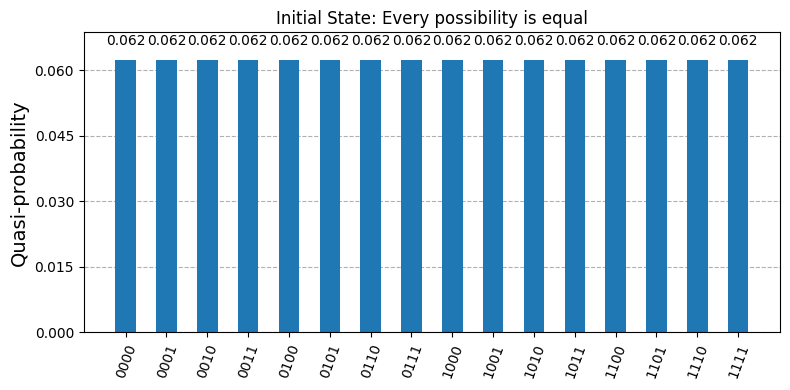

In [180]:
target = "0101"
n = 4
main_qc = QuantumCircuit(n)

# Step 1: Initialize Superposition
main_qc.h(range(n))
state = Statevector.from_instruction(main_qc)
show_probs(state, "Initial State: Every possibility is equal")

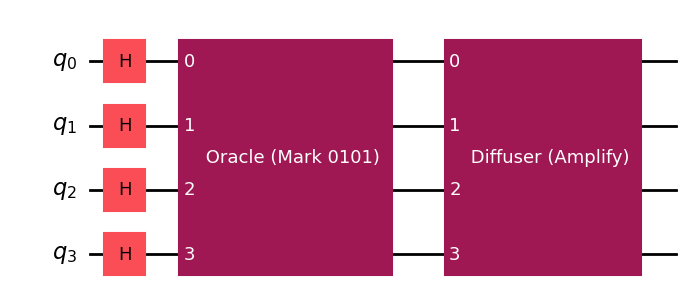

In [181]:
main_qc.append(oracle(target), range(n))
main_qc.append(diffuser(n), range(n))
main_qc.draw("mpl")

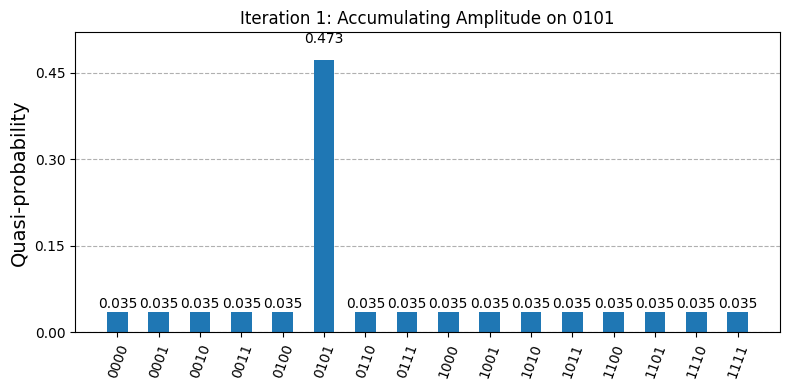

In [182]:
state = Statevector.from_instruction(main_qc)
show_probs(state, f"Iteration {1}: Accumulating Amplitude on {target}")

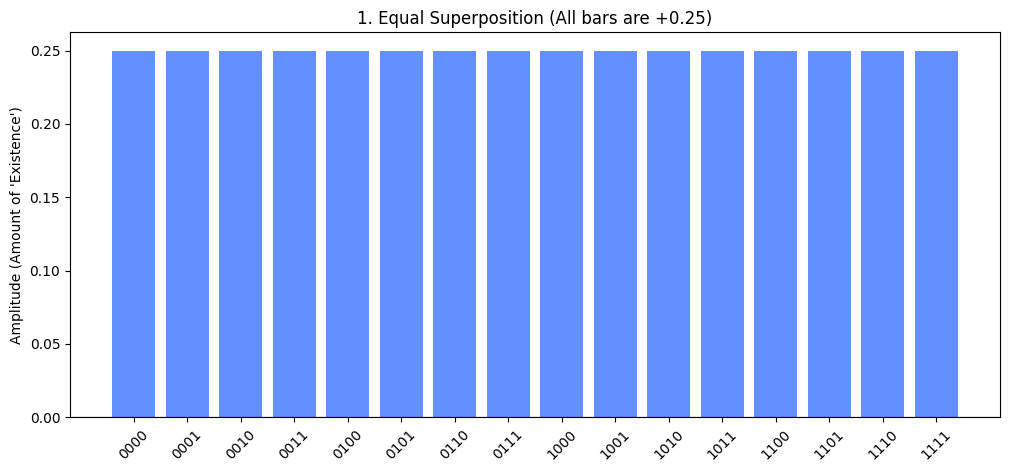

In [64]:
def plot_amplitudes(state, title="Statevector Amplitudes"):
    """Plots the real part of the amplitudes to show the sign flip."""
    amplitudes = state.data.real # Grover usually stays in the real plane
    labels = [format(i, '04b') for i in range(16)]
    
    plt.figure(figsize=(12, 5))
    colors = ['#648FFF' if a >= 0 else '#DC267C' for a in amplitudes]
    plt.bar(labels, amplitudes, color=colors)
    plt.xticks(rotation=45)
    plt.axhline(0, color='black', linewidth=0.8)
    plt.title(title)
    plt.ylabel("Amplitude (Amount of 'Existence')")
    plt.show()

# --- DEMONSTRATION ---
n = 4
target = "0101"
qc_demo = QuantumCircuit(n)

# 1. Start with Equal Superposition
qc_demo.h(range(n))
state_initial = Statevector.from_instruction(qc_demo)
plot_amplitudes(state_initial, "1. Equal Superposition (All bars are +0.25)")

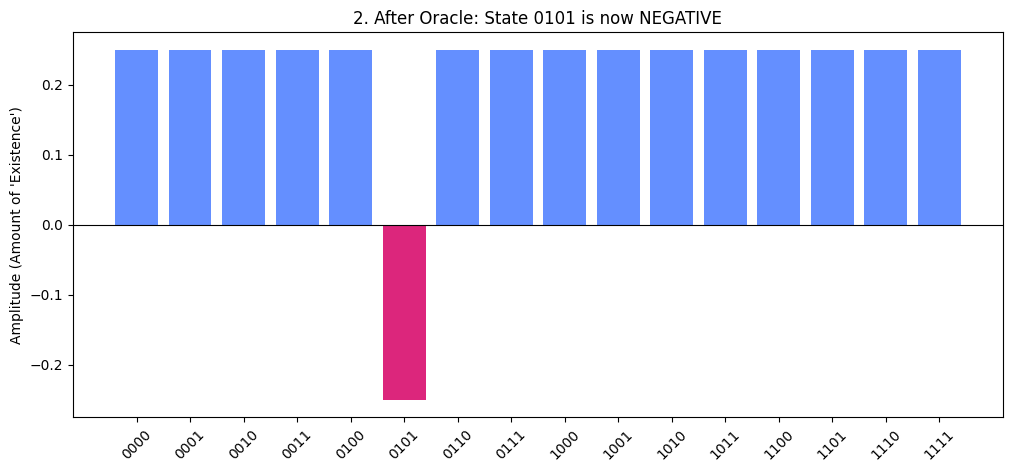

In [65]:
# 2. Apply the Oracle
qc_demo.append(get_oracle(target), range(n))
state_marked = Statevector.from_instruction(qc_demo)
plot_amplitudes(state_marked, f"2. After Oracle: State {target} is now NEGATIVE")

In [80]:
# Reset and run iterations
qc_search = QuantumCircuit(n)
qc_search.h(range(n))

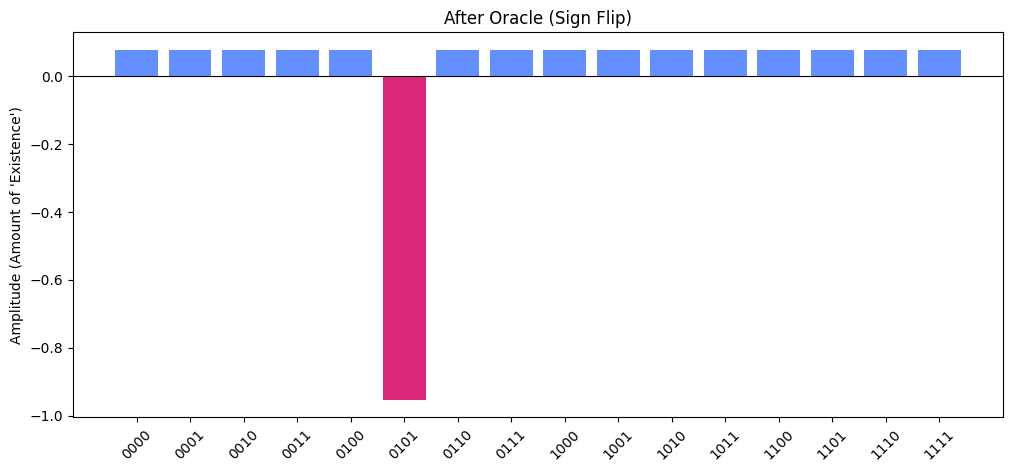

In [85]:
# Mark
qc_search.append(get_oracle(target), range(n))
state_after_oracle = Statevector.from_instruction(qc_search)
plot_amplitudes(state_after_oracle, f"After Oracle (Sign Flip)")

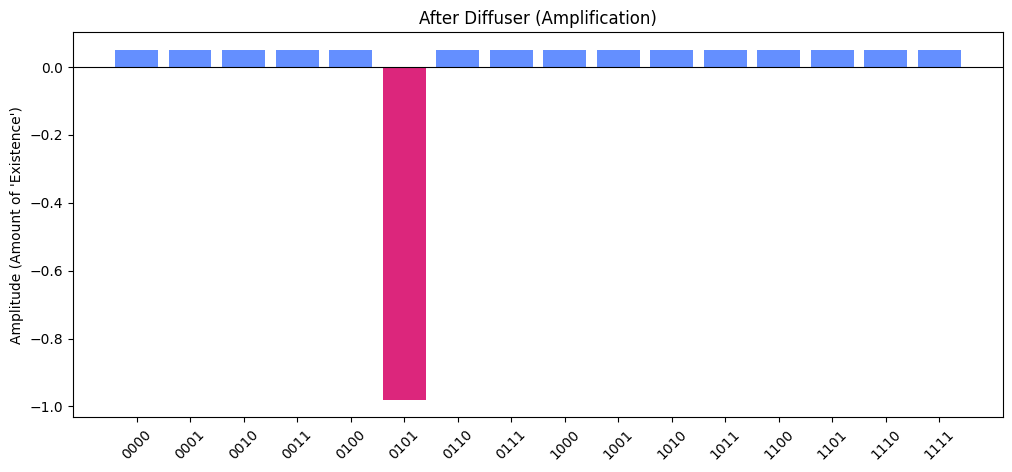

In [86]:
# Amplify
qc_search.append(get_diffuser(n), range(n))
state_after_diffuser = Statevector.from_instruction(qc_search)
plot_amplitudes(state_after_diffuser, f"After Diffuser (Amplification)")

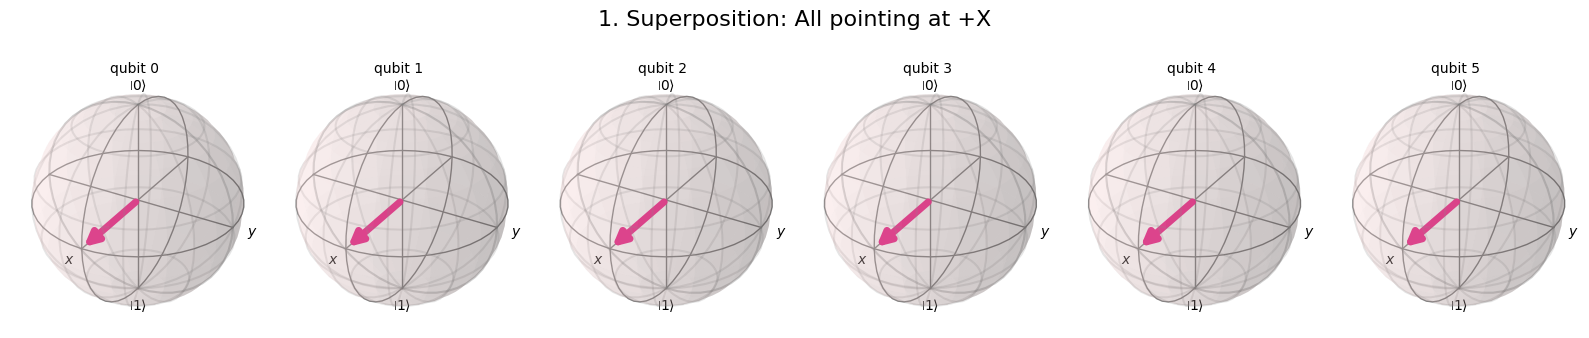

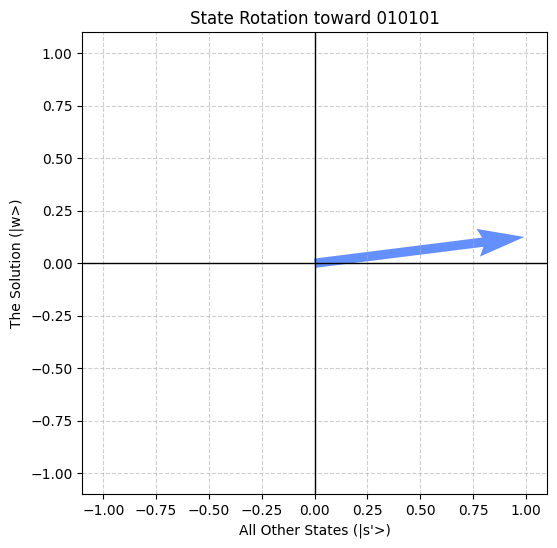

In [188]:
from qiskit.visualization import plot_bloch_multivector

# Setup 4 qubits for target 0101
n = 6
target = "010101"
qc_bloch = QuantumCircuit(n)

# 1. Start: Equal Superposition
qc_bloch.h(range(n))
state = Statevector.from_instruction(qc_bloch)
display(plot_bloch_multivector(state, title="1. Superposition: All pointing at +X"))
plot_grover_2d(state, target_str="010101")

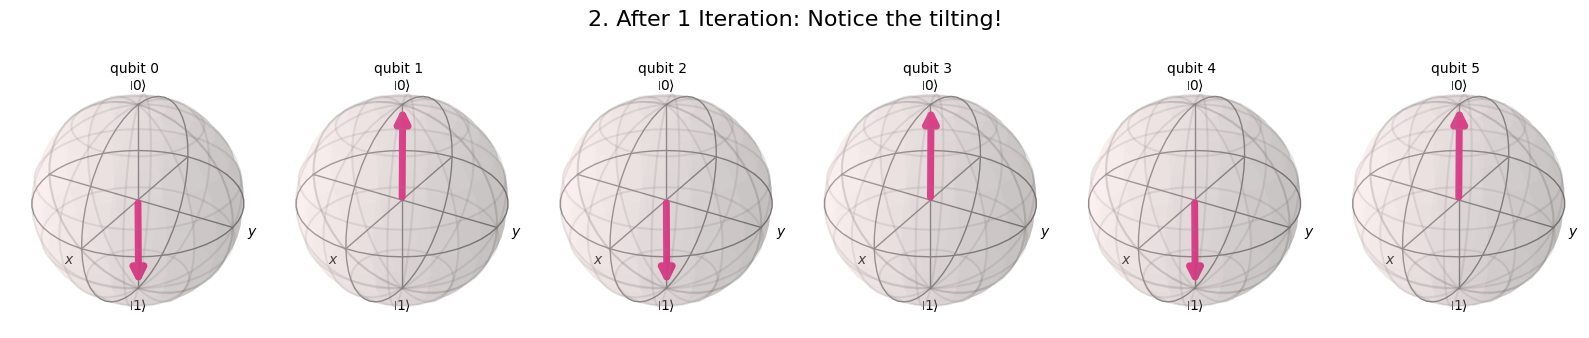

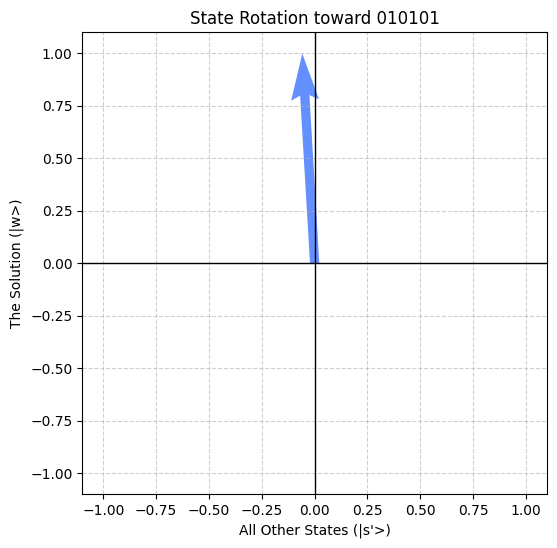

In [194]:
# 2. After 1 Iteration (Oracle + Diffuser)
qc_bloch.append(oracle(target), range(n))
qc_bloch.append(diffuser(n), range(n))
state = Statevector.from_instruction(qc_bloch)
display(plot_bloch_multivector(state, title="2. After 1 Iteration: Notice the tilting!"))
plot_grover_2d(state, target_str="010101")

In [ ]:
def plot_grover_2d(state, target_str):
    n = len(target_str)
    # 1. Define the 'Winner' vector |w>
    winner_vec = Statevector.from_label(target_str)
    
    # 2. Define the 'Non-winners' vector |s_prime>
    # This is the equal superposition of everything EXCEPT the winner
    all_states_sum = np.ones(2**n) / np.sqrt(2**n)
    # Orthogonalize it to the winner
    projection = np.dot(winner_vec.data.conj(), all_states_sum)
    s_prime_data = all_states_sum - projection * winner_vec.data
    s_prime_vec = s_prime_data / np.linalg.norm(s_prime_data)
    
    # 3. Calculate coordinates (x = projection on s_prime, y = projection on winner)
    x = np.real(np.dot(s_prime_vec.conj(), state.data))
    y = np.real(np.dot(winner_vec.data.conj(), state.data))
    
    # 4. Plotting
    plt.figure(figsize=(6,6))
    plt.quiver(0, 0, x, y, angles='xy', scale_units='xy', scale=1, color='#648FFF', width=0.02)
    plt.xlim(-1.1, 1.1); plt.ylim(-1.1, 1.1)
    plt.axhline(0, color='black', lw=1); plt.axvline(0, color='black', lw=1)
    plt.xlabel("All Other States (|s'>)"); plt.ylabel("The Solution (|w>)")
    plt.title(f"State Rotation toward {target_str}")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

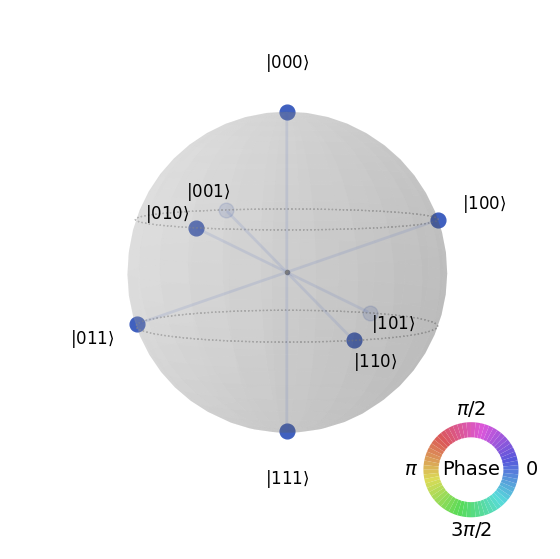

In [150]:
from qiskit.visualization import plot_state_qsphere

target = "010"
n = 3
# 1. Initial Superposition
# All nodes are the same size (equal probability) 
# and the same color (all in-phase)
qc_qs = QuantumCircuit(n)
qc_qs.h(range(n))
state = Statevector.from_instruction(qc_qs)
display(plot_state_qsphere(state))

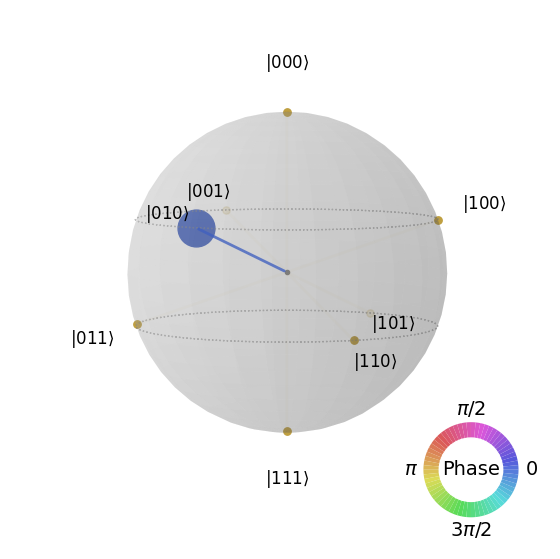

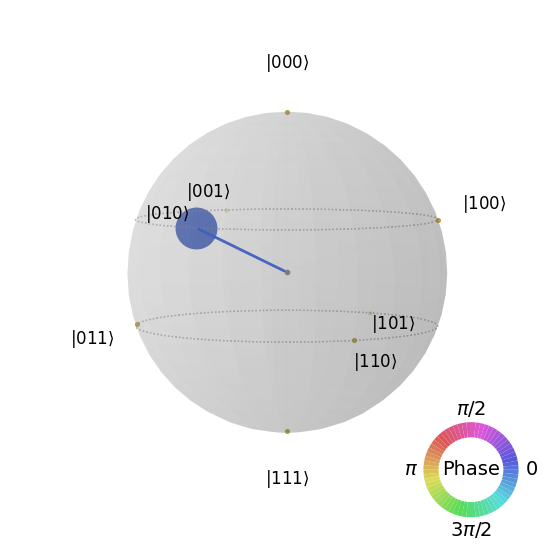

In [ ]:
# 2. After the Oracle (The Sign Flip)
# Watch the '0101' node! 
# It stays the same size, but its color will flip to the opposite 
# side of the color wheel (representing a 180-degree/pi phase shift).
qc_qs.append(oracle(target), range(n))
state = Statevector.from_instruction(qc_qs)
display(plot_state_qsphere(state))

# 3. After the Diffuser (The Amplification)
# The '0101' node physically grows larger than all the others.
qc_qs.append(diffuser(n), range(n))
state = Statevector.from_instruction(qc_qs)
display(plot_state_qsphere(state))